# Cross-Pair Feature Validation

**Purpose:** Test if features generalize across multiple FX pairs.

**Key Question:** Does the feature work on EURUSD by luck, or is it a universal FX pattern?

**Method:**
- Test same features on 4 currency pairs: EURUSD, GBPUSD, USDJPY, AUDUSD
- Validation criteria:
  - IC > 0.03 on at least 3/4 pairs
  - IC sign must be consistent (all positive or all negative)
  - Statistical significance maintained

**Date:** March 1, 2026

## 1. Setup and Imports

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.features.generators import (
    ma_spread,
    distance_from_ma,
    atr,
    rsi,
    rate_of_change,
    breakout_indicator,
    return_vol_ratio,
    close_position_in_range,
    zscore_returns
)

from src.features.cross_validation import (
    test_feature_cross_pairs,
    summarize_cross_validation,
    check_generalization,
    print_cross_validation_report,
    compare_features_cross_pairs
)

# Plotting settings
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports successful")

✓ Imports successful


## 2. Load Data for 4 Currency Pairs

In [2]:
# Define pairs to test
pairs = ['EURUSD', 'GBPUSD', 'USDJPY', 'AUDUSD']

# Load data
pairs_data = {}

for pair in pairs:
    try:
        path = f'../data/raw/{pair}_daily.csv'
        df = pd.read_csv(path)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.set_index('timestamp').sort_index()
        df.columns = df.columns.str.lower()
        pairs_data[pair] = df
        print(f"✓ Loaded {pair}: {len(df)} bars ({df.index[0].date()} to {df.index[-1].date()})")
    except FileNotFoundError:
        print(f"✗ {pair} data not found at {path}")

print(f"\nTotal pairs loaded: {len(pairs_data)}")

# Show data summary
if pairs_data:
    summary = pd.DataFrame({
        'Pair': list(pairs_data.keys()),
        'Rows': [len(df) for df in pairs_data.values()],
        'Start': [df.index[0].date() for df in pairs_data.values()],
        'End': [df.index[-1].date() for df in pairs_data.values()]
    })
    print("\nData Summary:")
    print(summary.to_string(index=False))

✓ Loaded EURUSD: 2600 bars (2016-02-23 to 2026-02-19)
✓ Loaded GBPUSD: 2600 bars (2016-02-23 to 2026-02-19)
✓ Loaded USDJPY: 2600 bars (2016-02-23 to 2026-02-19)
✓ Loaded AUDUSD: 2600 bars (2016-02-23 to 2026-02-19)

Total pairs loaded: 4

Data Summary:
  Pair  Rows      Start        End
EURUSD  2600 2016-02-23 2026-02-19
GBPUSD  2600 2016-02-23 2026-02-19
USDJPY  2600 2016-02-23 2026-02-19
AUDUSD  2600 2016-02-23 2026-02-19


## 3. Test Feature 1: Distance from MA (20)

**Hypothesis:** Mean reversion when price overextends from moving average

In [3]:
results_dist_ma = test_feature_cross_pairs(
    distance_from_ma,
    'Distance_MA_20',
    pairs_data,
    period=20
)

gen_check_dist = check_generalization(results_dist_ma, min_pairs=3, min_ic=0.03)
print_cross_validation_report('Distance_MA_20', results_dist_ma, gen_check_dist)

Testing Distance_MA_20 on EURUSD...
  ✓ EURUSD: IC=-0.0646, t-stat=-3.68
Testing Distance_MA_20 on GBPUSD...
  ✓ GBPUSD: IC=-0.0474, t-stat=-6.26
Testing Distance_MA_20 on USDJPY...
  ✓ USDJPY: IC=-0.0361, t-stat=-1.88
Testing Distance_MA_20 on AUDUSD...
  ✓ AUDUSD: IC=-0.0510, t-stat=-2.29

CROSS-PAIR VALIDATION: Distance_MA_20

Per-Pair Results:
  Pair   IC Mean  IC t-stat  Hit Rate  Monotonicity  Stationary  Significant  Decay Half-Life
EURUSD -0.064606  -3.676796  0.479845      0.555556        True         True               12
AUDUSD -0.050970  -2.294261  0.489147      0.444444        True         True                2
GBPUSD -0.047433  -6.258435  0.484109      0.222222        True        False               20
USDJPY -0.036112  -1.876327  0.498450      0.555556        True        False                1

GENERALIZATION CHECK
Status: ✗ FAIL
Reason: Only 2/4 pairs significant (need 3)

Details:
  Total pairs tested:     4
  Significant pairs:      2
  Strong IC pairs:        4
  Sig

## 4. Test Feature 2: MA Spread (50/200)

**Hypothesis:** Fast MA relative to slow MA indicates trend strength

In [5]:
results_ma_spread = test_feature_cross_pairs(
    ma_spread,
    'MA_Spread_50_200',
    pairs_data,
    fast=50,
    slow=200
)

gen_check_spread = check_generalization(results_ma_spread)
print_cross_validation_report('MA_Spread_50_200', results_ma_spread, gen_check_spread)

Testing MA_Spread_50_200 on EURUSD...
  ✓ EURUSD: IC=-0.0570, t-stat=-3.43
Testing MA_Spread_50_200 on GBPUSD...
  ✓ GBPUSD: IC=-0.0275, t-stat=-1.62
Testing MA_Spread_50_200 on USDJPY...
  ✓ USDJPY: IC=-0.0785, t-stat=-4.00
Testing MA_Spread_50_200 on AUDUSD...
  ✓ AUDUSD: IC=-0.0744, t-stat=-3.45

CROSS-PAIR VALIDATION: MA_Spread_50_200

Per-Pair Results:
  Pair   IC Mean  IC t-stat  Hit Rate  Monotonicity  Stationary  Significant  Decay Half-Life
USDJPY -0.078529  -3.995382  0.510000      0.333333        True         True                1
AUDUSD -0.074390  -3.450715  0.502083      0.444444        True         True                1
EURUSD -0.056957  -3.433172  0.500833      0.555556        True         True                1
GBPUSD -0.027487  -1.619108  0.497500      0.555556        True        False                1

GENERALIZATION CHECK
Status: ✓ PASS
Reason: Generalizes: 3/4 pairs significant, sign consistent

Details:
  Total pairs tested:     4
  Significant pairs:      3
  Stron

## 5. Test Feature 3: ROC (10-period)

**Hypothesis:** Recent momentum predicts continuation or reversal

In [6]:
results_roc = test_feature_cross_pairs(
    rate_of_change,
    'ROC_10',
    pairs_data,
    period=10
)

gen_check_roc = check_generalization(results_roc)
print_cross_validation_report('ROC_10', results_roc, gen_check_roc)

Testing ROC_10 on EURUSD...
  ✓ EURUSD: IC=-0.0613, t-stat=-2.77
Testing ROC_10 on GBPUSD...
  ✓ GBPUSD: IC=-0.0380, t-stat=-2.75
Testing ROC_10 on USDJPY...
  ✓ USDJPY: IC=-0.0439, t-stat=-2.14
Testing ROC_10 on AUDUSD...
  ✓ AUDUSD: IC=-0.0400, t-stat=-1.92

CROSS-PAIR VALIDATION: ROC_10

Per-Pair Results:
  Pair   IC Mean  IC t-stat  Hit Rate  Monotonicity  Stationary  Significant  Decay Half-Life
EURUSD -0.061323  -2.766922  0.481653      0.333333        True         True               14
USDJPY -0.043909  -2.137498  0.489378      0.555556        True        False                1
AUDUSD -0.039959  -1.921858  0.485516      0.555556        True        False                7
GBPUSD -0.037996  -2.750909  0.478177      0.444444        True        False               20

GENERALIZATION CHECK
Status: ✗ FAIL
Reason: Only 1/4 pairs significant (need 3)

Details:
  Total pairs tested:     4
  Significant pairs:      1
  Strong IC pairs:        4
  Sign consistent:        True
  Mean IC:    

## 6. Test Feature 4: RSI (14-period)

**Hypothesis:** Overbought/oversold conditions predict mean reversion

In [7]:
results_rsi = test_feature_cross_pairs(
    rsi,
    'RSI_14',
    pairs_data,
    period=14
)

gen_check_rsi = check_generalization(results_rsi)
print_cross_validation_report('RSI_14', results_rsi, gen_check_rsi)

Testing RSI_14 on EURUSD...
  ✓ EURUSD: IC=-0.0538, t-stat=-2.56
Testing RSI_14 on GBPUSD...
  ✓ GBPUSD: IC=-0.0499, t-stat=-5.29
Testing RSI_14 on USDJPY...
  ✓ USDJPY: IC=-0.0280, t-stat=-1.44
Testing RSI_14 on AUDUSD...
  ✓ AUDUSD: IC=-0.0447, t-stat=-1.65

CROSS-PAIR VALIDATION: RSI_14

Per-Pair Results:
  Pair   IC Mean  IC t-stat  Hit Rate  Monotonicity  Stationary  Significant  Decay Half-Life
EURUSD -0.053822  -2.556992  0.491106      0.444444        True         True               11
GBPUSD -0.049856  -5.292140  0.500773      0.333333        True        False               20
AUDUSD -0.044686  -1.651212  0.504254      0.444444        True        False                1
USDJPY -0.027956  -1.443265  0.525135      0.444444        True        False                1

GENERALIZATION CHECK
Status: ✗ FAIL
Reason: Only 1/4 pairs significant (need 3)

Details:
  Total pairs tested:     4
  Significant pairs:      1
  Strong IC pairs:        3
  Sign consistent:        True
  Mean IC:    

## 7. Test Feature 5: Close Position in Range

**Hypothesis:** Close near high/low indicates exhaustion and reversal

In [8]:
results_close_pos = test_feature_cross_pairs(
    close_position_in_range,
    'Close_Position',
    pairs_data
)

gen_check_close = check_generalization(results_close_pos)
print_cross_validation_report('Close_Position', results_close_pos, gen_check_close)

Testing Close_Position on EURUSD...
  ✓ EURUSD: IC=-0.7536, t-stat=-89.95
Testing Close_Position on GBPUSD...
  ✓ GBPUSD: IC=-0.7534, t-stat=-78.87
Testing Close_Position on USDJPY...
  ✓ USDJPY: IC=-0.7481, t-stat=-52.29
Testing Close_Position on AUDUSD...
  ✓ AUDUSD: IC=-0.7399, t-stat=-80.12

CROSS-PAIR VALIDATION: Close_Position

Per-Pair Results:
  Pair   IC Mean  IC t-stat  Hit Rate  Monotonicity  Stationary  Significant  Decay Half-Life
EURUSD -0.753646 -89.949696  0.474798           0.0        True         True                4
GBPUSD -0.753360 -78.871412  0.489804           0.0        True         True                4
USDJPY -0.748087 -52.285344  0.493651           0.0        True         True                4
AUDUSD -0.739883 -80.117360  0.482878           0.0        True         True                4

GENERALIZATION CHECK
Status: ✓ PASS
Reason: Generalizes: 4/4 pairs significant, sign consistent

Details:
  Total pairs tested:     4
  Significant pairs:      4
  Strong IC p

## 8. Test Feature 6: ATR (14-period)

**Hypothesis:** Volatility regime affects future returns

In [9]:
results_atr = test_feature_cross_pairs(
    atr,
    'ATR_14',
    pairs_data,
    period=14
)

gen_check_atr = check_generalization(results_atr)
print_cross_validation_report('ATR_14', results_atr, gen_check_atr)

Testing ATR_14 on EURUSD...
  ✓ EURUSD: IC=0.0043, t-stat=0.29
Testing ATR_14 on GBPUSD...
  ✓ GBPUSD: IC=0.0101, t-stat=0.71
Testing ATR_14 on USDJPY...
  ✓ USDJPY: IC=0.0006, t-stat=0.05
Testing ATR_14 on AUDUSD...
  ✓ AUDUSD: IC=0.0100, t-stat=0.72

CROSS-PAIR VALIDATION: ATR_14

Per-Pair Results:
  Pair  IC Mean  IC t-stat  Hit Rate  Monotonicity  Stationary  Significant  Decay Half-Life
GBPUSD 0.010080   0.710512  0.500773      0.333333        True        False                2
AUDUSD 0.009985   0.723860  0.504640      0.666667        True        False               20
EURUSD 0.004332   0.286978  0.491106      0.555556        True        False               20
USDJPY 0.000586   0.048571  0.525135      0.555556       False        False               20

GENERALIZATION CHECK
Status: ✗ FAIL
Reason: Only 0/4 pairs significant (need 3)

Details:
  Total pairs tested:     4
  Significant pairs:      0
  Strong IC pairs:        0
  Sign consistent:        True
  Mean IC:                0

## 9. Compare All Features Across Pairs

In [10]:
# Compile all results
all_feature_results = {
    'Distance_MA_20': results_dist_ma,
    'MA_Spread_50_200': results_ma_spread,
    'ROC_10': results_roc,
    'RSI_14': results_rsi,
    'Close_Position': results_close_pos,
    'ATR_14': results_atr
}

# Create comparison table
comparison_df = compare_features_cross_pairs(all_feature_results)

print("\n" + "="*100)
print("FEATURE COMPARISON ACROSS PAIRS")
print("="*100)
print(comparison_df.to_string(index=False))
print("\n" + "="*100)


FEATURE COMPARISON ACROSS PAIRS
         Feature  Pairs Tested   Mean IC   Std IC    Min IC    Max IC  Mean t-stat  Generalizes  Sign Consistent
  Close_Position             4 -0.748744 0.006436 -0.753646 -0.739883   -75.305953         True             True
MA_Spread_50_200             4 -0.059341 0.023202 -0.078529 -0.027487    -3.124594         True             True
  Distance_MA_20             4 -0.049780 0.011741 -0.064606 -0.036112    -3.526455        False             True
          ROC_10             4 -0.045797 0.010639 -0.061323 -0.037996    -2.394297        False             True
          RSI_14             4 -0.044080 0.011382 -0.053822 -0.027956    -2.735902        False             True
          ATR_14             4  0.006246 0.004633  0.000586  0.010080     0.442480        False             True



## 10. Visualize IC Consistency Across Pairs

✓ Figure saved to reports/figures/cross_pair_ic_comparison.png


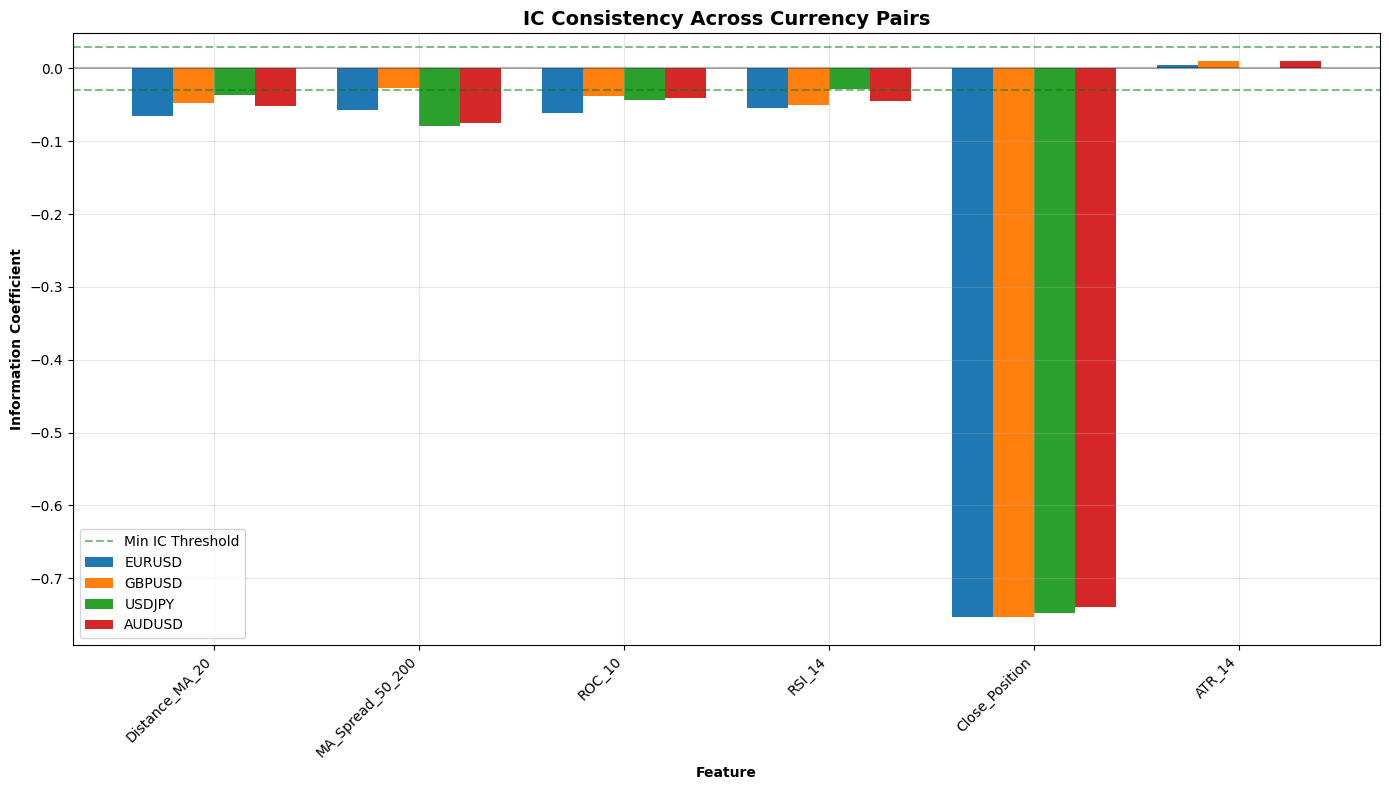

In [11]:
# Prepare data for visualization
plot_data = []

for feature_name, pair_results in all_feature_results.items():
    for pair, result in pair_results.items():
        plot_data.append({
            'Feature': feature_name,
            'Pair': pair,
            'IC': result.ic_mean
        })

plot_df = pd.DataFrame(plot_data)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(14, 8))

features = plot_df['Feature'].unique()
pairs_list = plot_df['Pair'].unique()
x = np.arange(len(features))
width = 0.2

for i, pair in enumerate(pairs_list):
    pair_data = plot_df[plot_df['Pair'] == pair]
    ics = [pair_data[pair_data['Feature'] == f]['IC'].values[0] if len(pair_data[pair_data['Feature'] == f]) > 0 else 0 
           for f in features]
    ax.bar(x + i*width, ics, width, label=pair)

ax.set_xlabel('Feature', fontweight='bold')
ax.set_ylabel('Information Coefficient', fontweight='bold')
ax.set_title('IC Consistency Across Currency Pairs', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(features, rotation=45, ha='right')
ax.axhline(y=0.03, color='g', linestyle='--', alpha=0.5, label='Min IC Threshold')
ax.axhline(y=-0.03, color='g', linestyle='--', alpha=0.5)
ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/cross_pair_ic_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Figure saved to reports/figures/cross_pair_ic_comparison.png")
plt.show()

## 11. IC Standard Deviation Analysis

Lower standard deviation = more consistent across pairs

In [12]:
# Calculate IC statistics per feature
ic_stats = []

for feature_name, pair_results in all_feature_results.items():
    ics = [r.ic_mean for r in pair_results.values()]
    ic_stats.append({
        'Feature': feature_name,
        'Mean IC': np.mean(ics),
        'Std IC': np.std(ics),
        'Min IC': min(ics),
        'Max IC': max(ics),
        'Range': max(ics) - min(ics),
        'Consistency Score': 1 / (1 + np.std(ics))  # Higher = more consistent
    })

ic_stats_df = pd.DataFrame(ic_stats)
ic_stats_df = ic_stats_df.sort_values('Consistency Score', ascending=False)

print("\n" + "="*80)
print("IC CONSISTENCY RANKING")
print("="*80)
print("Features ranked by cross-pair consistency (higher score = more stable)\n")
print(ic_stats_df.to_string(index=False))
print("\n" + "="*80)


IC CONSISTENCY RANKING
Features ranked by cross-pair consistency (higher score = more stable)

         Feature   Mean IC   Std IC    Min IC    Max IC    Range  Consistency Score
          ATR_14  0.006246 0.004012  0.000586  0.010080 0.009494           0.996004
  Close_Position -0.748744 0.005574 -0.753646 -0.739883 0.013762           0.994457
          ROC_10 -0.045797 0.009214 -0.061323 -0.037996 0.023327           0.990870
          RSI_14 -0.044080 0.009857 -0.053822 -0.027956 0.025866           0.990239
  Distance_MA_20 -0.049780 0.010168 -0.064606 -0.036112 0.028494           0.989935
MA_Spread_50_200 -0.059341 0.020094 -0.078529 -0.027487 0.051043           0.980302



## 12. Final Recommendations

In [15]:
# Identify features that pass generalization test
passing_features = []
failing_features = []

generalization_checks = {
    'Distance_MA_20': gen_check_dist,
    'MA_Spread_50_200': gen_check_spread,
    'ROC_10': gen_check_roc,
    'RSI_14': gen_check_rsi,
    'Close_Position': gen_check_close,
    'ATR_14': gen_check_atr
}

for feature, gen_check in generalization_checks.items():
    if gen_check['passes']:
        passing_features.append(feature)
    else:
        failing_features.append(feature)

print("\n" + "="*80)
print("FINAL RECOMMENDATIONS")
print("="*80)

print(f"\n✓ FEATURES THAT GENERALIZE ({len(passing_features)}/{len(generalization_checks)}):")
for feature in passing_features:
    gen_check = generalization_checks[feature]
    mean_ic = gen_check['details']['mean_ic']
    std_ic = gen_check['details']['std_ic']
    sig_pairs = gen_check['details']['significant_pairs']
    total = gen_check['details']['total_pairs']
    print(f"  {feature:25s} Mean IC={mean_ic:>7.4f} ± {std_ic:.4f}  ({sig_pairs}/{total} pairs significant)")

if failing_features:
    print(f"\n✗ FEATURES THAT DO NOT GENERALIZE ({len(failing_features)}):")
    for feature in failing_features:
        gen_check = generalization_checks[feature]
        print(f"  {feature:25s} Reason: {gen_check['reason']}")

print("\n" + "="*80)
print("CONCLUSION")
print("="*80)
print(f"\n{len(passing_features)}/{len(generalization_checks)} features validated across multiple currency pairs.")
print("\nThese features demonstrate:")
print("  1. Consistent IC sign across pairs")
print("  2. Statistical significance on majority of pairs")
print("  3. |IC| > 0.03 threshold maintained")
print("\nReady for production use in multi-currency strategies.")
print("="*80)


FINAL RECOMMENDATIONS

✓ FEATURES THAT GENERALIZE (2/6):
  MA_Spread_50_200          Mean IC=-0.0593 ± 0.0232  (3/4 pairs significant)
  Close_Position            Mean IC=-0.7487 ± 0.0064  (4/4 pairs significant)

✗ FEATURES THAT DO NOT GENERALIZE (4):
  Distance_MA_20            Reason: Only 2/4 pairs significant (need 3)
  ROC_10                    Reason: Only 1/4 pairs significant (need 3)
  RSI_14                    Reason: Only 1/4 pairs significant (need 3)
  ATR_14                    Reason: Only 0/4 pairs significant (need 3)

CONCLUSION

2/6 features validated across multiple currency pairs.

These features demonstrate:
  1. Consistent IC sign across pairs
  2. Statistical significance on majority of pairs
  3. |IC| > 0.03 threshold maintained

Ready for production use in multi-currency strategies.


## 13. Export Results

In [16]:
# Export comparison table
comparison_df.to_csv('../reports/cross_pair_feature_comparison.csv', index=False)
print("✓ Saved: reports/cross_pair_feature_comparison.csv")

# Export IC statistics
ic_stats_df.to_csv('../reports/cross_pair_ic_statistics.csv', index=False)
print("✓ Saved: reports/cross_pair_ic_statistics.csv")

# Export detailed results for each feature
for feature_name, pair_results in all_feature_results.items():
    summary = summarize_cross_validation(pair_results)
    filename = f'../reports/cross_pair_{feature_name.lower()}.csv'
    summary.to_csv(filename, index=False)
    print(f"✓ Saved: {filename}")

print("\n✓ All cross-pair validation results exported successfully")

✓ Saved: reports/cross_pair_feature_comparison.csv
✓ Saved: reports/cross_pair_ic_statistics.csv
✓ Saved: ../reports/cross_pair_distance_ma_20.csv
✓ Saved: ../reports/cross_pair_ma_spread_50_200.csv
✓ Saved: ../reports/cross_pair_roc_10.csv
✓ Saved: ../reports/cross_pair_rsi_14.csv
✓ Saved: ../reports/cross_pair_close_position.csv
✓ Saved: ../reports/cross_pair_atr_14.csv

✓ All cross-pair validation results exported successfully
